# dopri5 vs. fixed-step Euler: why guidance needs Euler

Compares the adaptive `dopri5` ODE solver (used for standard sampling)
against the fixed-step Euler integrator in `guidance/euler_density_integrator.py`
(used when guidance is on), with guidance off throughout so the comparison
isolates the integrator itself. Covers:

1. Why guidance needs a fixed-step solver.
2. Runtime, mean energy, and energy-W2 to the true target energy
   distribution, without density tracking.
3. Runtime with exact density tracking, on a few samples.
4. Orientation flips: what they are, and how step count affects their rate.

## Setup

Loads the trained ECNF++ model and the alanine-dipeptide (`Ace-A-Nme`)
evaluation context.

In [1]:
from __future__ import annotations

import time
from pathlib import Path

import hydra
import matplotlib.pyplot as plt
import numpy as np
import torch
from dotenv import load_dotenv
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra

from transferable_samplers.evaluation.metrics.wasserstein_distances import energy_wasserstein
from transferable_samplers.guidance.euler_density_integrator import generate_proposal_guided_euler
from transferable_samplers.utils.init_resume_utils import resolve_init


def find_repo_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "pyproject.toml").exists() and (p / "configs").is_dir():
            return p
    raise RuntimeError(
        "Could not locate the repo root from the notebook's cwd "
        f"({start}). Launch Jupyter from inside the repo, or set REPO_ROOT by hand."
    )


REPO_ROOT = find_repo_root(Path.cwd())
CONFIG_DIR = str(REPO_ROOT / "configs")
OUT_DIR = REPO_ROOT / "tests" / "guidance" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(REPO_ROOT / ".env", override=True)  # reads SCRATCH_DIR, etc.

print(f"REPO_ROOT={REPO_ROOT}")

REPO_ROOT=/workspace/ECNF_Guidance


In [2]:
SEQUENCE = "Ace-A-Nme"
SEED = 42


def load_model_and_data():
    GlobalHydra.instance().clear()
    with initialize_config_dir(version_base="1.3", config_dir=CONFIG_DIR):
        cfg = compose(
            config_name="eval",
            overrides=["experiment=single_system/eval/ecnf++_Ace-A-Nme_snis"],
        )

    datamodule = hydra.utils.instantiate(cfg.data)
    datamodule.prepare_data()  # no-op if already downloaded

    model = hydra.utils.instantiate(cfg.model)
    state_dict = resolve_init(
        init_ckpt_path=cfg.get("ckpt_path"),
        init_hf_state_dict_path=cfg.get("hf_state_dict_path"),
        scratch_dir=cfg.paths.scratch_dir,
    )
    model.load_state_dict(state_dict)
    return model, datamodule, cfg.data.num_atoms


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

model, datamodule, num_atoms = load_model_and_data()
model = model.to(device).eval()

eval_ctx = datamodule.prepare_eval(sequence=SEQUENCE, stage="test")

print(f"num_atoms={num_atoms}, atol=rtol={model.atol:g}")

device: cuda


/workspace/ECNF_Guidance/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


Model weights downloaded successfully to /workspace/scratch/transferable-samplers/model-weights


num_atoms=22, atol=rtol=0.0001


## 1. Why not dopri5?

`FlowMatchingModule._integrate` solves the flow ODE with an adaptive
Dormand-Prince solver (`dopri5`, via `torchdyn`'s `NeuralODE`): it picks its
own step count and locations to meet an error tolerance (`atol`/`rtol`),
independent of any external process. Guided sampling instead teleports the
state by a control shift at *every* integration step (`cxt = x + gamma*u`),
so the number of steps directly bounds how many chances guidance has to
correct the trajectory. A fixed-step Euler integrator gives an explicit,
chosen number of evenly-spaced steps to act at; an adaptive solver does not.

The trade-off: Euler is only first-order accurate, so it needs many more
steps than dopri5 for comparable solution accuracy, and tracking exact
log-density with Euler costs a full Jacobian (`d` backward passes) per step,
against dopri5's cheaper continuous stochastic trace estimate. The rest of
this notebook quantifies both sides of that trade-off.

In [3]:
torch.manual_seed(SEED)
z_demo = model.prior.sample(8, num_atoms, device=device)

nfe_before = model.nfe
with torch.no_grad():
    model._integrate(model.net, z_demo.clone(), encodings=None, reverse=False, compute_dlogp=False)
dopri5_nfe = model.nfe - nfe_before

print(f"dopri5 used {dopri5_nfe} function evaluations for these 8 samples -- "
      f"chosen by its own error control, not by us.")
print("A fixed-step Euler integrator instead takes exactly as many evenly-spaced "
      "steps as requested (e.g. 250 below), each one a place guidance can act.")

Your vector field does not have `nn.Parameters` to optimize.


dopri5 used 92 function evaluations for these 8 samples -- chosen by its own error control, not by us.
A fixed-step Euler integrator instead takes exactly as many evenly-spaced steps as requested (e.g. 250 below), each one a place guidance can act.


## 2. Unguided comparison, no density tracking

Same prior samples integrated with dopri5 and with Euler at a few step
counts, guidance off (`alpha=0`, `n_inner=0`), comparing wall-clock runtime,
mean target (OpenMM) energy, and energy-W2 to the true target energy
distribution (`eval_ctx.true_data.E_target`).

In [4]:
NUM_SAMPLES = 128
EULER_STEPS_LIST = [25, 50, 100, 200, 250]


def energy_and_w2(x: torch.Tensor) -> tuple[float, float]:
    with torch.no_grad():
        e = eval_ctx.target_energy.energy(x.to(device))
    w2 = energy_wasserstein(pred_energy=e.cpu(), true_energy=eval_ctx.true_data.E_target, prefix="tmp")["tmp/energy-w2"]
    return e.mean().item(), w2


def sync() -> None:
    if device == "cuda":
        torch.cuda.synchronize()


results_no_density = []

torch.manual_seed(SEED)
z = model.prior.sample(NUM_SAMPLES, num_atoms, device=device)

t0 = time.time()
with torch.no_grad():
    x_dopri5, _ = model._integrate(model.net, z.clone(), encodings=None, reverse=False, compute_dlogp=False)
sync()
dopri5_runtime = time.time() - t0
mean_e, w2 = energy_and_w2(x_dopri5)
results_no_density.append({"method": "dopri5", "runtime_s": dopri5_runtime, "mean_energy": mean_e, "energy_w2": w2})

for n in EULER_STEPS_LIST:
    torch.manual_seed(SEED)  # reproduces the same z via model.prior.sample(...) inside the call
    t0 = time.time()
    x_euler, _, _ = generate_proposal_guided_euler(
        model, NUM_SAMPLES, num_atoms, lambda x1, t: (x1 * 0.0).sum(),
        alpha=0.0, n_inner=0, use_score_deviation=False, beta=0.0, lam=0.0,
        n_steps=n, device=device, track_density=False,
    )
    sync()
    runtime = time.time() - t0
    mean_e, w2 = energy_and_w2(x_euler.detach())
    results_no_density.append({"method": f"euler_{n}", "runtime_s": runtime, "mean_energy": mean_e, "energy_w2": w2})

print(f"{'method':>10} | {'runtime (s)':>12} | {'mean energy':>12} | {'energy-W2':>10}")
for r in results_no_density:
    print(f"{r['method']:>10} | {r['runtime_s']:>12.3f} | {r['mean_energy']:>12.3f} | {r['energy_w2']:>10.3f}")

Your vector field does not have `nn.Parameters` to optimize.


    method |  runtime (s) |  mean energy |  energy-W2
    dopri5 |        4.271 |      -28.418 |      6.576
  euler_25 |        1.272 |      -36.482 |     13.546
  euler_50 |        2.516 |      -35.093 |     12.136
 euler_100 |        5.006 |      -32.987 |      9.969
 euler_200 |       10.162 |      -31.168 |      8.339
 euler_250 |       12.550 |      -30.682 |      7.955


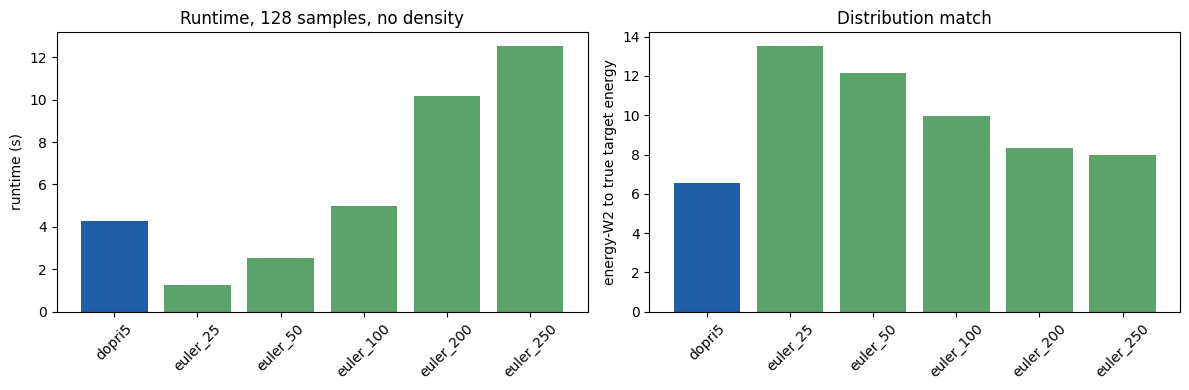

In [5]:
methods = [r["method"] for r in results_no_density]
colors = ["#1f5fa8" if m == "dopri5" else "#5aa469" for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(methods, [r["runtime_s"] for r in results_no_density], color=colors)
axes[0].set_ylabel("runtime (s)")
axes[0].set_title(f"Runtime, {NUM_SAMPLES} samples, no density")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(methods, [r["energy_w2"] for r in results_no_density], color=colors)
axes[1].set_ylabel("energy-W2 to true target energy")
axes[1].set_title("Distribution match")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

## 3. Runtime with exact density tracking, few samples

Exact log-density under Euler costs a full Jacobian per step (`d` backward
passes, `d = num_atoms * 3`), so this only stays cheap with a small batch.
Compares dopri5 (Hutchinson-trace `dlogp`, `compute_dlogp=True`) against
Euler's exact log-determinant at a few step counts.

In [6]:
NUM_SAMPLES_DENSITY = 8
EULER_STEPS_DENSITY_LIST = [100, 250]

results_density = []

torch.manual_seed(SEED)
z_small = model.prior.sample(NUM_SAMPLES_DENSITY, num_atoms, device=device)
logp_z = model.prior.logp(z_small)

t0 = time.time()
with torch.no_grad():
    x_dopri5_d, dlogp_dopri5 = model._integrate(model.net, z_small.clone(), encodings=None, reverse=False, compute_dlogp=True)
sync()
runtime = time.time() - t0
logq_dopri5 = (logp_z + dlogp_dopri5).mean().item()
results_density.append({"method": "dopri5", "runtime_s": runtime, "logq_mean": logq_dopri5})

for n in EULER_STEPS_DENSITY_LIST:
    torch.manual_seed(SEED)
    t0 = time.time()
    x_euler_d, neg_logq_euler, valid = generate_proposal_guided_euler(
        model, NUM_SAMPLES_DENSITY, num_atoms, lambda x1, t: (x1 * 0.0).sum(),
        alpha=0.0, n_inner=0, use_score_deviation=False, beta=0.0, lam=0.0,
        n_steps=n, device=device, track_density=True, raise_on_orientation_failure=False,
    )
    sync()
    runtime = time.time() - t0
    logq_euler = (-neg_logq_euler[valid]).mean().item()
    results_density.append({"method": f"euler_{n}", "runtime_s": runtime, "logq_mean": logq_euler})

print(f"{'method':>10} | {'runtime (s)':>12} | {'mean logq':>10}")
for r in results_density:
    print(f"{r['method']:>10} | {r['runtime_s']:>12.3f} | {r['logq_mean']:>10.3f}")

Your vector field does not have `nn.Parameters` to optimize.


    method |  runtime (s) |  mean logq
    dopri5 |       27.340 |    155.493
 euler_100 |       36.378 |    190.571
 euler_250 |       90.896 |    168.456


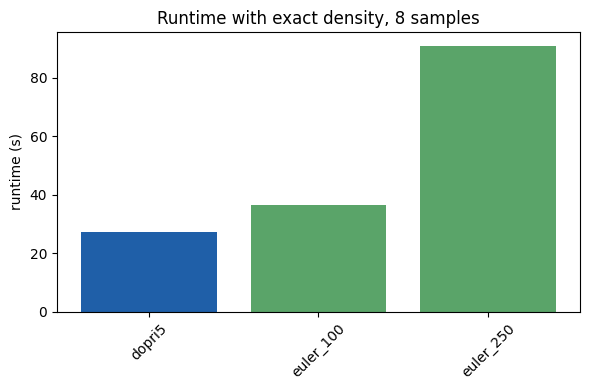

In [7]:
methods_d = [r["method"] for r in results_density]
colors_d = ["#1f5fa8" if m == "dopri5" else "#5aa469" for m in methods_d]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(methods_d, [r["runtime_s"] for r in results_density], color=colors_d)
ax.set_ylabel("runtime (s)")
ax.set_title(f"Runtime with exact density, {NUM_SAMPLES_DENSITY} samples")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

## 4. Orientation flips

The exact log-density formula assumes each step's local Jacobian determinant
stays positive (orientation-preserving). `guided_euler_exact` checks this via
`slogdet`'s sign at every step; when a step folds the map for a sample
(`det <= 0`), that sample's log-density is no longer valid under the
change-of-variables formula. `raise_on_orientation_failure=False` keeps
integrating and reports which samples stayed valid at every step instead of
raising. Coarser discretization (fewer steps) folds more often.

In [8]:
NUM_SAMPLES_FLIP = 8
EULER_STEPS_FLIP_LIST = [10, 25, 50, 100, 250]

flip_rates = []
for n in EULER_STEPS_FLIP_LIST:
    torch.manual_seed(SEED)
    _, _, valid = generate_proposal_guided_euler(
        model, NUM_SAMPLES_FLIP, num_atoms, lambda x1, t: (x1 * 0.0).sum(),
        alpha=0.0, n_inner=0, use_score_deviation=False, beta=0.0, lam=0.0,
        n_steps=n, device=device, track_density=True, raise_on_orientation_failure=False,
    )
    flip_rate = 1.0 - valid.float().mean().item()
    flip_rates.append(flip_rate)
    num_flipped = int(round(flip_rate * NUM_SAMPLES_FLIP))
    print(f"n_steps={n:>4}: {num_flipped}/{NUM_SAMPLES_FLIP} samples had an orientation flip ({flip_rate:.1%})")

n_steps=  10: 3/8 samples had an orientation flip (37.5%)


n_steps=  25: 2/8 samples had an orientation flip (25.0%)


n_steps=  50: 3/8 samples had an orientation flip (37.5%)


n_steps= 100: 0/8 samples had an orientation flip (0.0%)


n_steps= 250: 0/8 samples had an orientation flip (0.0%)


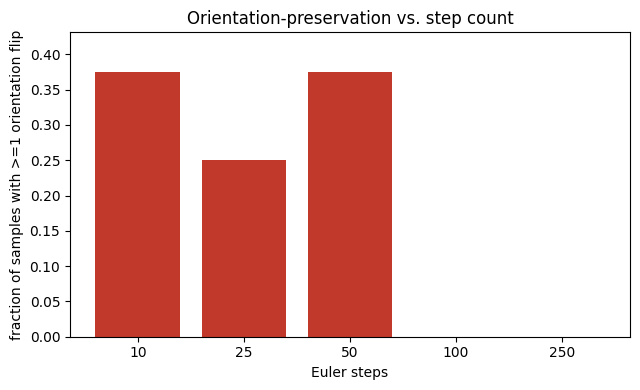

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar([str(n) for n in EULER_STEPS_FLIP_LIST], flip_rates, color="#c0392b")
ax.set_xlabel("Euler steps")
ax.set_ylabel("fraction of samples with >=1 orientation flip")
ax.set_title("Orientation-preservation vs. step count")
ax.set_ylim(0, max(flip_rates + [0.05]) * 1.15)
fig.tight_layout()
plt.show()

## Next steps

- Raise `NUM_SAMPLES`/`NUM_SAMPLES_DENSITY`/`NUM_SAMPLES_FLIP` for tighter
  estimates.
- Extend `EULER_STEPS_LIST`/`EULER_STEPS_DENSITY_LIST`/`EULER_STEPS_FLIP_LIST`
  to see where each metric plateaus.